# Atividade — Perfis de lojas com K-Means

Agrupar lojas por movimento, faturamento e comportamento de vendas.

**Arquivo de dados:** `lojas_kmeans.csv`

> Regra central: as colunas de referência servem somente para avaliar o resultado no final. Elas não podem entrar em `X`.

## 1. Importe as bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score

SEMENTE = 42

## 2. Carregue e inspecione os dados

Use `pd.read_csv`, `head`, `shape`, `info`, `describe` e `isna().sum()`.

In [2]:
# TODO: carregue lojas_kmeans.csv
df = pd.read_csv("lojas_kmeans.csv")
display(df.head())
print("Dimensoes:", df.shape)
display(df.describe(include="all"))
print("Ausentes por coluna:\n", df.isna().sum())

,loja_id,faturamento_mensal,clientes_dia,ticket_medio,taxa_conversao_pct,estoque_medio_itens,perfil_referencia
0,LOJ001,51436,30,55.17,23.6,872,pequeno_movimento
1,LOJ002,42325,34,57.15,21.9,672,pequeno_movimento
2,LOJ003,38222,24,51.17,16.1,762,pequeno_movimento
3,LOJ004,43704,43,60.65,16.5,1050,pequeno_movimento
4,LOJ005,46489,44,46.44,20.5,972,pequeno_movimento


Dimensoes: (90, 7)


,loja_id,faturamento_mensal,clientes_dia,ticket_medio,taxa_conversao_pct,estoque_medio_itens,perfil_referencia
count,90,90.000000,90.000000,90.000000,90.000000,90.000000,90
unique,90,NaN,NaN,NaN,NaN,NaN,3
top,LOJ001,NaN,NaN,NaN,NaN,NaN,pequeno_movimento
freq,1,NaN,NaN,NaN,NaN,NaN,30
mean,NaN,143221.100000,88.788889,69.874222,24.585556,1464.500000,NaN
std,NaN,78528.005377,50.275755,38.586926,7.243898,526.546182,NaN
min,NaN,33832.000000,20.000000,20.940000,8.900000,406.000000,NaN
25%,NaN,54224.000000,43.250000,41.110000,19.525000,956.250000,NaN
50%,NaN,147674.500000,72.000000,49.305000,24.700000,1452.000000,NaN
75%,NaN,214436.500000,143.500000,112.047500,29.575000,1829.250000,NaN


Ausentes por coluna:
 loja_id                0
faturamento_mensal     0
clientes_dia           0
ticket_medio           0
taxa_conversao_pct     0
estoque_medio_itens    0
perfil_referencia      0
dtype: int64


## 3. Prepare X e padronize

Remova `loja_id` e `perfil_referencia`. Use somente as cinco variáveis numéricas e aplique `StandardScaler`.

In [3]:
# TODO: informe as colunas numericas
colunas = ["faturamento_mensal", "clientes_dia", "ticket_medio", "taxa_conversao_pct", "estoque_medio_itens"]
X = df[colunas]
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X)

## 4. Escolha K

Teste K de 2 a 6. Calcule a inércia e o índice de silhueta e produza dois gráficos.

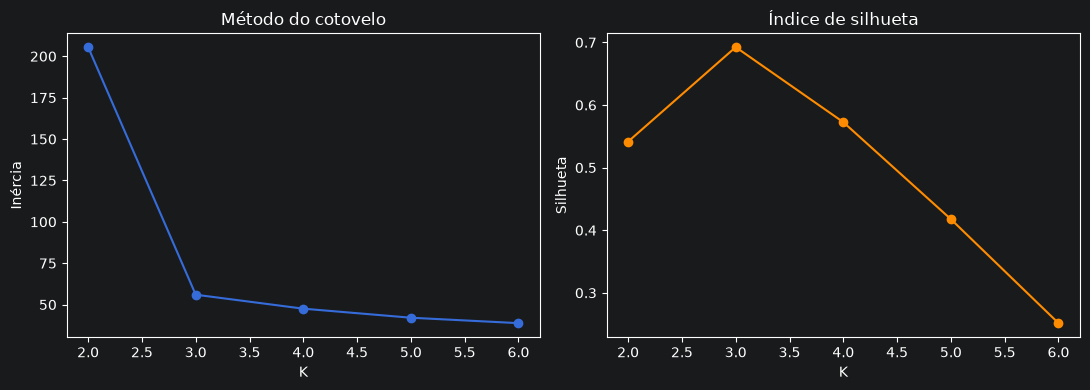

In [4]:
# TODO: complete o teste de K
valores_k = range(2, 7)
inercias, silhuetas = [], []
for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
    grupos = modelo.fit_predict(X_padronizado)
    inercias.append(modelo.inertia_)
    silhuetas.append(silhouette_score(X_padronizado, grupos))

# TODO: desenhe os dois graficos
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
eixos[0].plot(list(valores_k), inercias, marker="o")
eixos[0].set(title="Método do cotovelo", xlabel="K", ylabel="Inércia")
eixos[1].plot(list(valores_k), silhuetas, marker="o", color="darkorange")
eixos[1].set(title="Índice de silhueta", xlabel="K", ylabel="Silhueta")
plt.tight_layout()
plt.show()

## 5. Treine o modelo final

Use K=3, acrescente a coluna `cluster`, mostre as médias por grupo e faça uma visualização com PCA.

,faturamento_mensal,clientes_dia,ticket_medio,taxa_conversao_pct,estoque_medio_itens
cluster,,,,,
0,234098.13,75.73,121.99,25.58,1497.4
1,47909.73,37.07,47.76,16.73,855.5
2,147655.43,153.57,39.87,31.45,2040.6


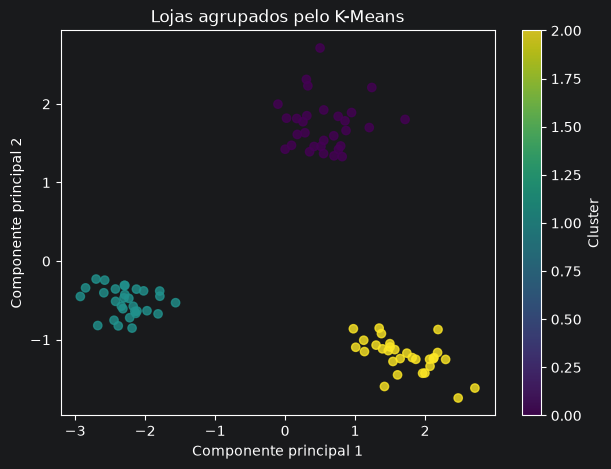

In [5]:
# TODO: ajuste o modelo final
kmeans = KMeans(n_clusters=3, random_state=SEMENTE, n_init=10)
clusters = kmeans.fit_predict(X_padronizado)
df["cluster"] = clusters
resumo = df.groupby("cluster")[colunas].mean().round(2)
display(resumo)

# TODO: reduza para duas dimensoes com PCA e desenhe o grafico
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_padronizado)
plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap="viridis", alpha=0.8)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Lojas agrupados pelo K-Means")
plt.colorbar(label="Cluster")
plt.show()

## 6. Avaliação do agrupamento

Somente depois do treinamento, compare os clusters com a coluna de referência usando tabela cruzada e ARI.

In [6]:
# TODO: complete a avaliacao
tabela = pd.crosstab(df["perfil_referencia"], df["cluster"], rownames=["referencia"], colnames=["cluster"])

# TODO: calcule o ARI
ari = adjusted_rand_score(df["perfil_referencia"], clusters)
display(tabela)
print(f"ARI: {ari:.4f}")

cluster,0,1,2
referencia,,,
alto_valor,30,0,0
alto_volume,0,0,30
pequeno_movimento,0,30,0


ARI: 1.0000
